2.21.0


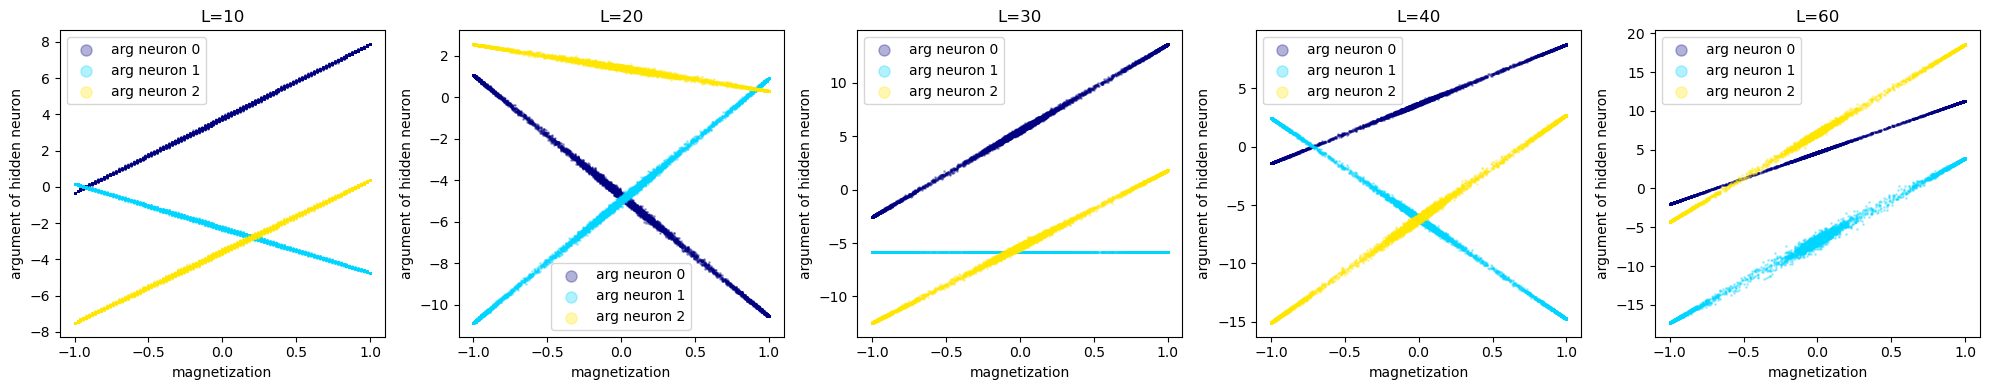

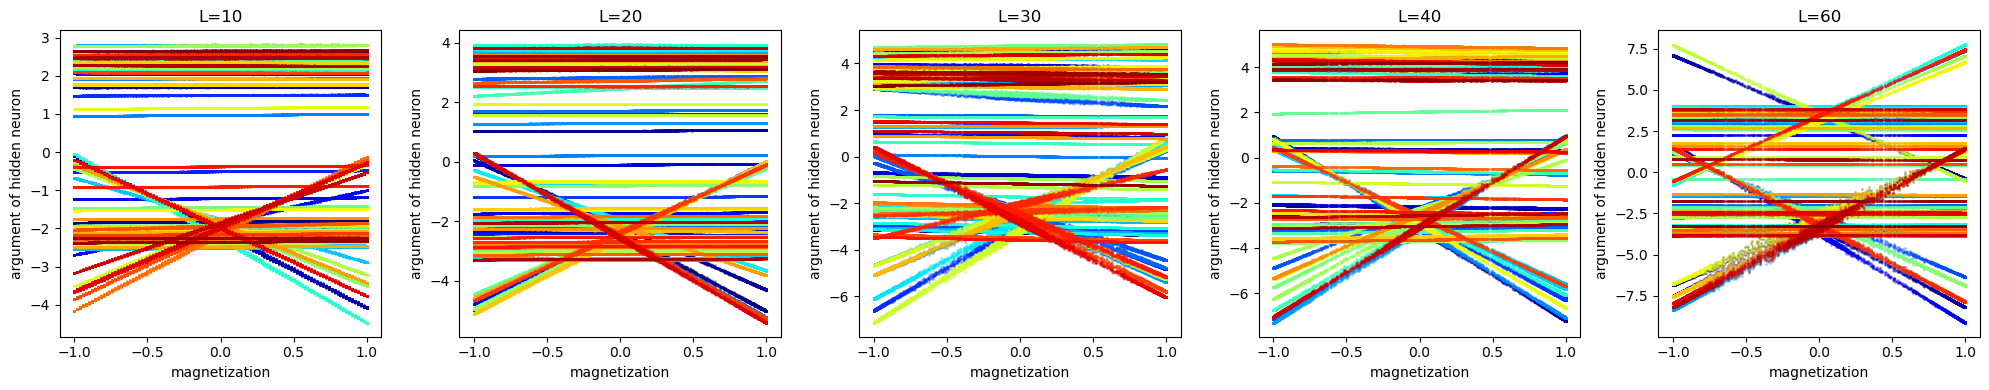

"\nfor l in L:\n    new_model = tf.keras.models.load_model(f'../models_3/ising_classifier_L{l}.h5', compile=False)\n    #models_3.append(new_model)\n    weights = new_model.get_weights()[0]\n"

In [5]:
import numpy as np
import tensorflow as tf
print(tf.__version__)
from matplotlib import pyplot as plt
import pandas as pd


# Same regularizer used during training in model_creation_mario.py — needs to be
# defined here so Keras can deserialize the Dense layer config when loading.

@tf.keras.utils.register_keras_serializable()
class VarianceL2Regularizer(tf.keras.regularizers.Regularizer):
    #L2 plus a penalty on the variance of each neuron's weight vector across
    #input sites. Built from tf.math.reduce_variance and tf.reduce_sum — pushes
    #h_j toward being a function of the magnetization alone.
    def __init__(self, l2, lam_var):
        self.l2 = l2
        self.lam_var = lam_var

    def __call__(self, w):
        return (self.l2 * tf.reduce_sum(tf.square(w))
                + self.lam_var * tf.reduce_sum(tf.math.reduce_variance(w, axis=0)))

    def get_config(self):
        return {'l2': float(self.l2), 'lam_var': float(self.lam_var)}
    
CUSTOM_OBJECTS = {'VarianceL2Regularizer': VarianceL2Regularizer}

"""
@tf.keras.utils.register_keras_serializable()
class WeightVarianceRegularizer(tf.keras.regularizers.Regularizer):
    def __init__(self, lam_var):
        self.lam_var = lam_var
    def __call__(self, w):
        return self.lam_var * tf.reduce_sum(tf.math.reduce_variance(w, axis=0))
    def get_config(self):
        return {'lam_var': float(self.lam_var)}

CUSTOM_OBJECTS = {'WeightVarianceRegularizer': WeightVarianceRegularizer}
"""

L = [10, 20, 30, 40, 60]

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, l in enumerate(L):
    new_model = tf.keras.models.load_model(f'../ian/ian_repo/models_3/ising_classifier_L{l}.h5', compile=False)
    data = np.load(f"../data_test/L{l}_ising.npz")
    weights, bias = new_model.layers[1].get_weights()
    hidden_args = data['spins'] @ weights + bias
    m = np.mean(data['spins'], axis=1)
    for j in range(hidden_args.shape[1]):
        im = axs[i].scatter(m, hidden_args[:, j], s=1, alpha=0.3, color=plt.cm.jet(j/weights.shape[1]), label = f'arg neuron {j}')
    axs[i].set_title(f'L={l}')
    axs[i].set_xlabel('magnetization')
    axs[i].set_ylabel('argument of hidden neuron')
    axs[i].legend(markerscale=8)
plt.tight_layout()
plt.savefig('plots/hidden_args_3.png')
plt.show()

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, l in enumerate(L):
    new_model = tf.keras.models.load_model(f'../ian/ian_repo/models_100_op/ising_classifier_L{l}.h5', compile=False)
    data = np.load(f"../data_test/L{l}_ising.npz")
    weights, bias = new_model.layers[1].get_weights()
    hidden_args = data['spins'] @ weights + bias
    m = np.mean(data['spins'], axis=1)
    for j in range(hidden_args.shape[1]):
        im = axs[i].scatter(m, hidden_args[:, j], s=1, alpha=0.3, color=plt.cm.jet(j/weights.shape[1]), label = f'arg neuron {j}')
    axs[i].set_title(f'L={l}')
    axs[i].set_xlabel('magnetization')
    axs[i].set_ylabel('argument of hidden neuron')
    #axs[i].legend(markerscale=8)
plt.tight_layout()
plt.savefig('plots/hidden_args_100.png')
plt.show()


"""
for l in L:
    new_model = tf.keras.models.load_model(f'../models_3/ising_classifier_L{l}.h5', compile=False)
    #models_3.append(new_model)
    weights = new_model.get_weights()[0]
""" 
